## Isolation Forest

In [ ]:
import sys
sys.path.insert(0, '..')

In [1]:
# Configuration
CONFIG = {
    'dataset_path': 'data/train_test_network.csv',
    'enable_monitoring': True,
    'random_state': 42
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print("\n  Important: random_state must match training notebook to ensure same test set!")

Configuration:
  dataset_path: data/train_test_network.csv
  enable_monitoring: True
  random_state: 42

  Important: random_state must match training notebook to ensure same test set!


In [2]:
from ton_iot_pipeline import load_and_split_data

X_train, X_val, X_test, y_train, y_val, y_test, _, _, _ = load_and_split_data(
    filepath=CONFIG['dataset_path'],
    random_state=CONFIG['random_state']
)

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...
Dataset shape: (211043, 44)
Features: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Data split (stratified by attack type):
  Train: 147,730 samples (70.0%)
  Val:   31,656 samples (15.0%)
  Test:  31,657 samples (15.0%)

Label distribution (0=normal, 1=attack):
  Train: 76.31% attacks
  Val:   76.31% attacks
  Test:  76.31% attacks


In [3]:
from preprocessing import BasicIFPreprocessor, FancyIFPreprocessor

preprocessor = BasicIFPreprocessor()
X_train = preprocessor.fit_transform(X_train)
# taking only normal data for training
X_train = X_train[y_train == 0]
X_val = preprocessor.transform(X_val)

In [4]:
X_val_data = X_val.copy()
y_val_data = y_val.copy()

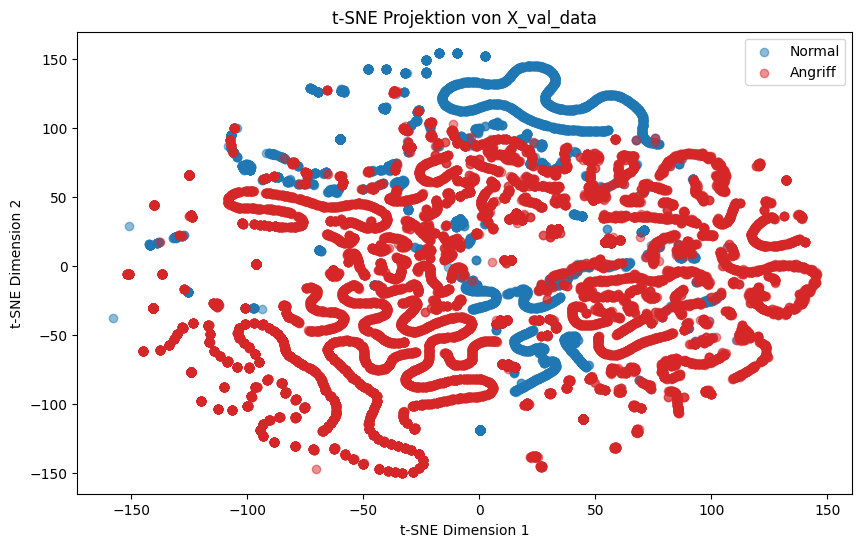

In [5]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
# tsne only for numerical features

X_val_numeric = X_val_data.select_dtypes(include=[np.number])

tsne = TSNE(n_components=2, random_state=42)
X_val_2d = tsne.fit_transform(X_val_numeric)
plt.figure(figsize=(10, 6))
plt.scatter(
    X_val_2d[y_val_data == 0, 0], X_val_2d[y_val_data == 0, 1],
    c='#1f77b4', label='Normal', alpha=0.5
)
plt.scatter(
    X_val_2d[y_val_data == 1, 0], X_val_2d[y_val_data == 1, 1],
    c='#d62728', label='Angriff', alpha=0.5
)
plt.legend()
plt.title('t-SNE Projektion von X_val_data')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


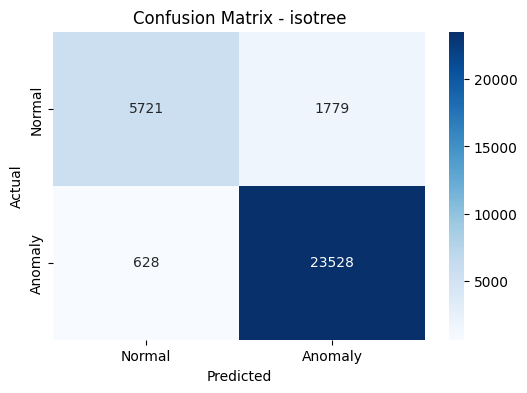

Classification Report:
               precision    recall  f1-score   support

      Normal       0.90      0.76      0.83      7500
     Angriff       0.93      0.97      0.95     24156

    accuracy                           0.92     31656
   macro avg       0.92      0.87      0.89     31656
weighted avg       0.92      0.92      0.92     31656



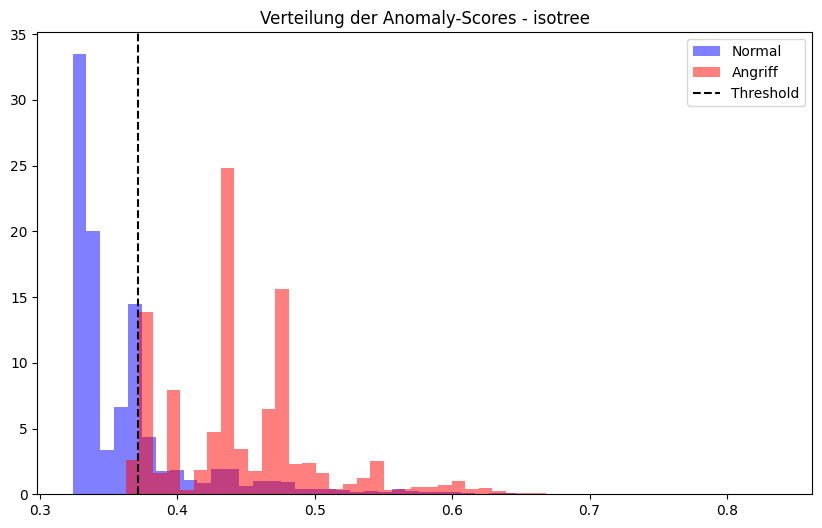

In [5]:
import isotree
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from ton_iot_utils import plot_score_distribution, plot_confusion_matrix

iforest = isotree.IsolationForest(
    ndim=1,
    ntrees=100,
    sample_size=2048,
    missing_action="fail",
    coefs="uniform",
    max_depth=8,
    ntry=1,
    scoring_metric="adj_depth",
    random_state=42,
)

iforest.fit(X_train)
scores = iforest.predict(X_val_data)
threshold = np.percentile(scores, 20) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_data, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = iforest.decision_function(X_val_data)
report = classification_report(y_val_data, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(iforest, X_val_data, y_val_data, threshold, "isotree")

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


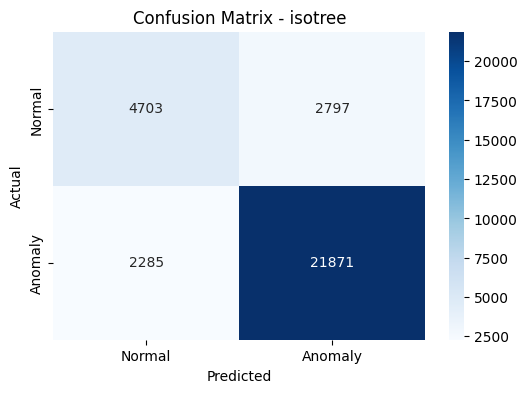

Classification Report:
               precision    recall  f1-score   support

      Normal       0.67      0.63      0.65      7500
     Angriff       0.89      0.91      0.90     24156

    accuracy                           0.84     31656
   macro avg       0.78      0.77      0.77     31656
weighted avg       0.84      0.84      0.84     31656



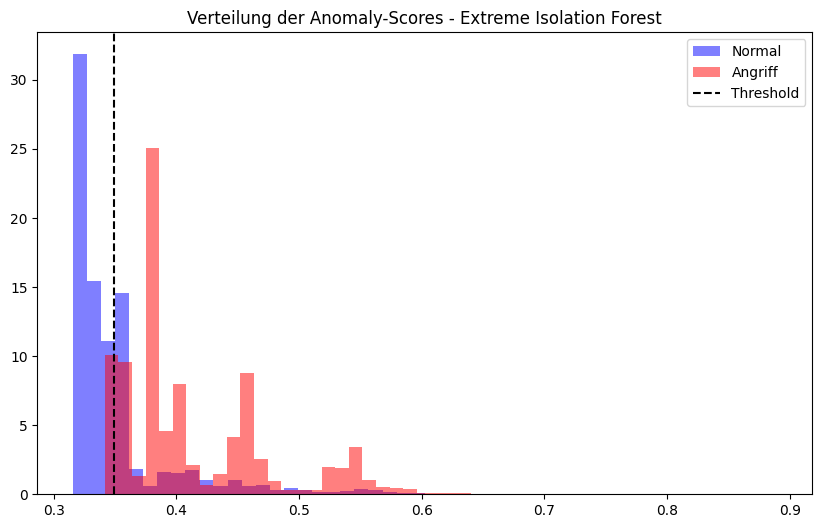

In [6]:
import isotree
import numpy as np
from sklearn.metrics import confusion_matrix
# David Setup (High-Performance Variante)
eif = isotree.IsolationForest(
    ndim=2,
    ntrees=100,
    sample_size=2048,
    missing_action="fail",
    max_depth=8,
    ntry=1,
    coefs="uniform",
    standardize_data=False,
    categ_split_type="subset",
    scoring_metric="adj_depth",
    random_state=42,
)

eif.fit(X_train)
scores = eif.predict(X_val_data)
threshold = np.percentile(scores, 20) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_data, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = eif.decision_function(X_val_data)
report = classification_report(y_val_data, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(eif, X_val_data, y_val_data, threshold, "Extreme Isolation Forest")

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


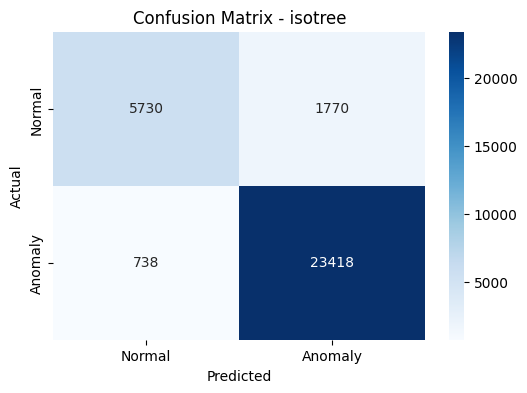

Classification Report:
               precision    recall  f1-score   support

      Normal       0.89      0.76      0.82      7500
     Angriff       0.93      0.97      0.95     24156

    accuracy                           0.92     31656
   macro avg       0.91      0.87      0.88     31656
weighted avg       0.92      0.92      0.92     31656



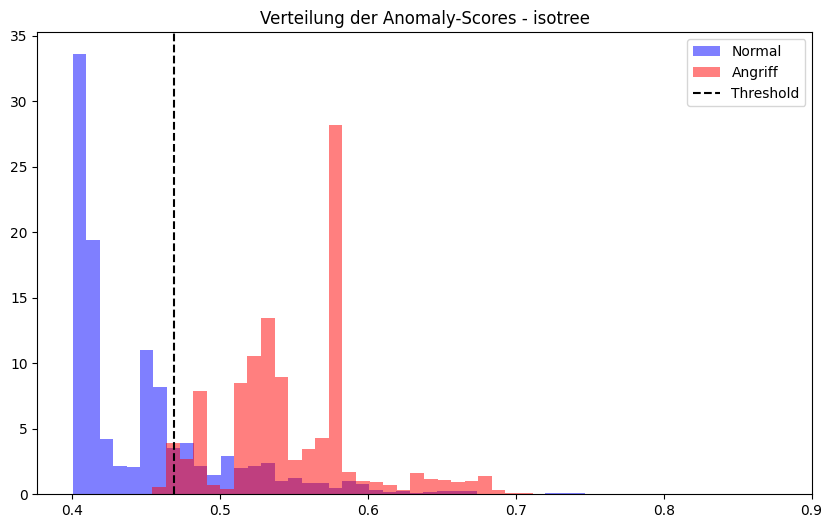

In [7]:
import isotree
import numpy as np
from sklearn.metrics import confusion_matrix
# David Setup (High-Performance Variante)
sciforest = isotree.IsolationForest(
    ndim=2,
    ntrees=100,
    sample_size=2048,
    missing_action="fail",
    max_depth=8,
    coefs="normal",
    ntry=10,
    prob_pick_avg_gain=0.9,
    penalize_range=True,
    random_state=42,
    scoring_metric="depth"
)

sciforest.fit(X_train)
scores = sciforest.predict(X_val_data)
threshold = np.percentile(scores, 20) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_data, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = sciforest.decision_function(X_val_data)
report = classification_report(y_val_data, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(sciforest, X_val_data, y_val_data, threshold, "isotree")

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


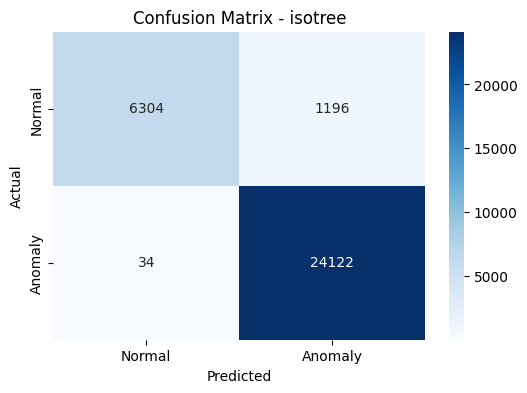

Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.84      0.91      7500
     Angriff       0.95      1.00      0.98     24156

    accuracy                           0.96     31656
   macro avg       0.97      0.92      0.94     31656
weighted avg       0.96      0.96      0.96     31656



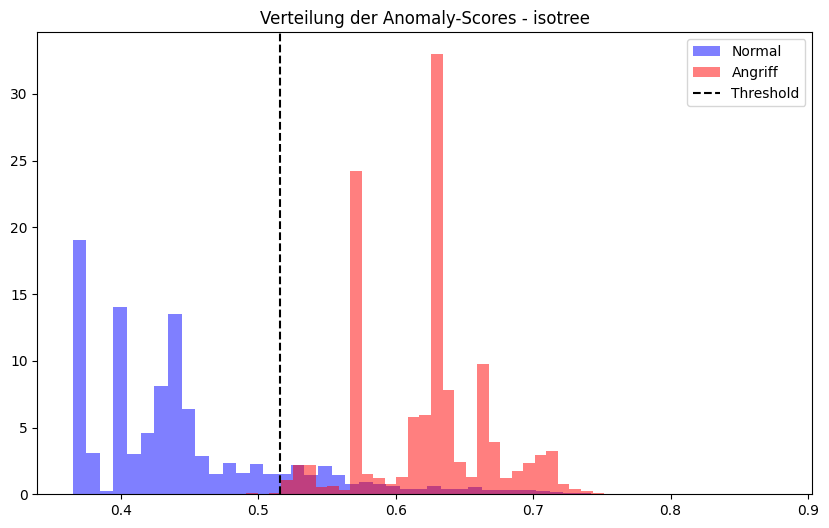

In [8]:
fcf = isotree.IsolationForest(
    ndim=2,
    sample_size=2048,
    ntrees=200,
    prob_pick_pooled_gain=0.9,
    penalize_range=True,
    ntry=1,
    coefs="normal",
    missing_action="fail",
    scoring_metric="depth",
    random_state=42
)

fcf.fit(X_train)
scores = fcf.predict(X_val_data)
threshold = np.percentile(scores, 20) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_data, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = fcf.decision_function(X_val_data)
report = classification_report(y_val_data, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(fcf, X_val_data, y_val_data, threshold, "isotree")

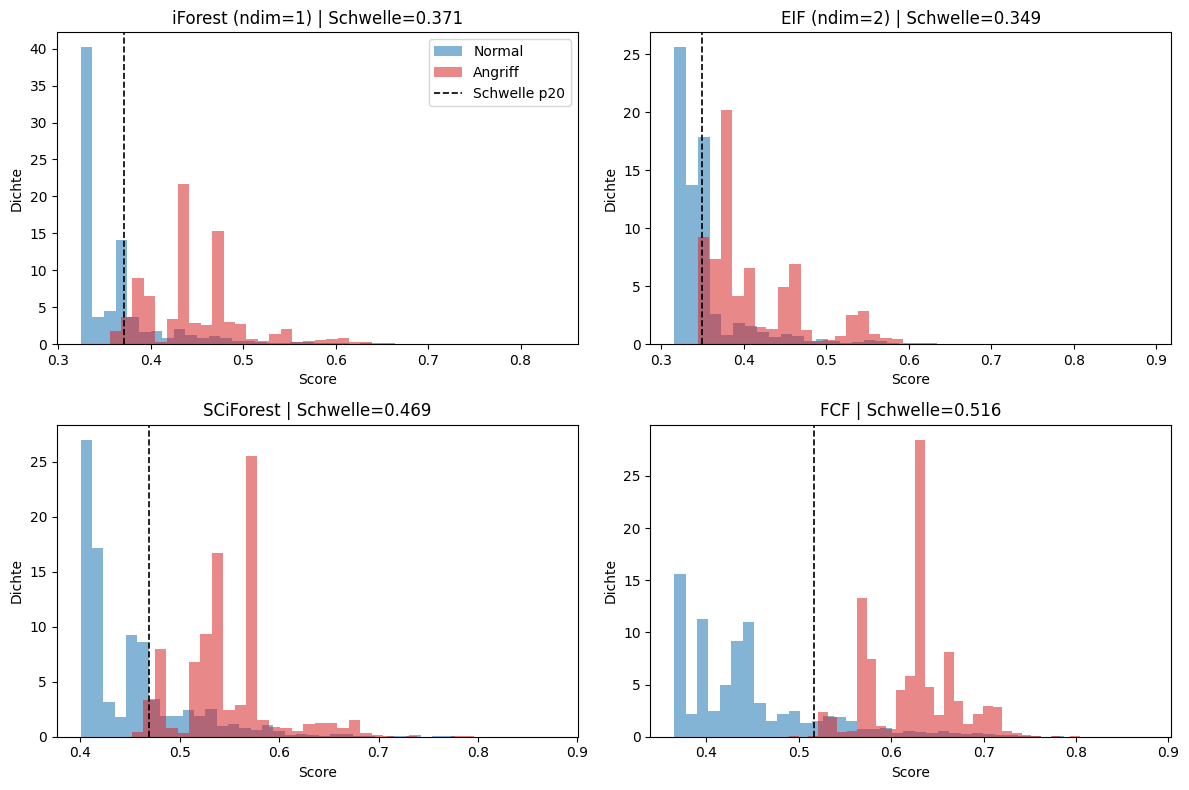

In [10]:
from ton_iot_utils import plot_score_distributions_grid

models_for_grid = {
    "iForest (ndim=1)": iforest,
    "EIF (ndim=2)": eif,
    "SCiForest": sciforest,
    "FCF": fcf,
}

score_thresholds = plot_score_distributions_grid(
    models_for_grid,
    X_val_data,
    y_val_data,
    percentile=20,
    bins=40,
)


## Feature Importance

Berechne Importances für 4 Modelle (Top 15 Features)...


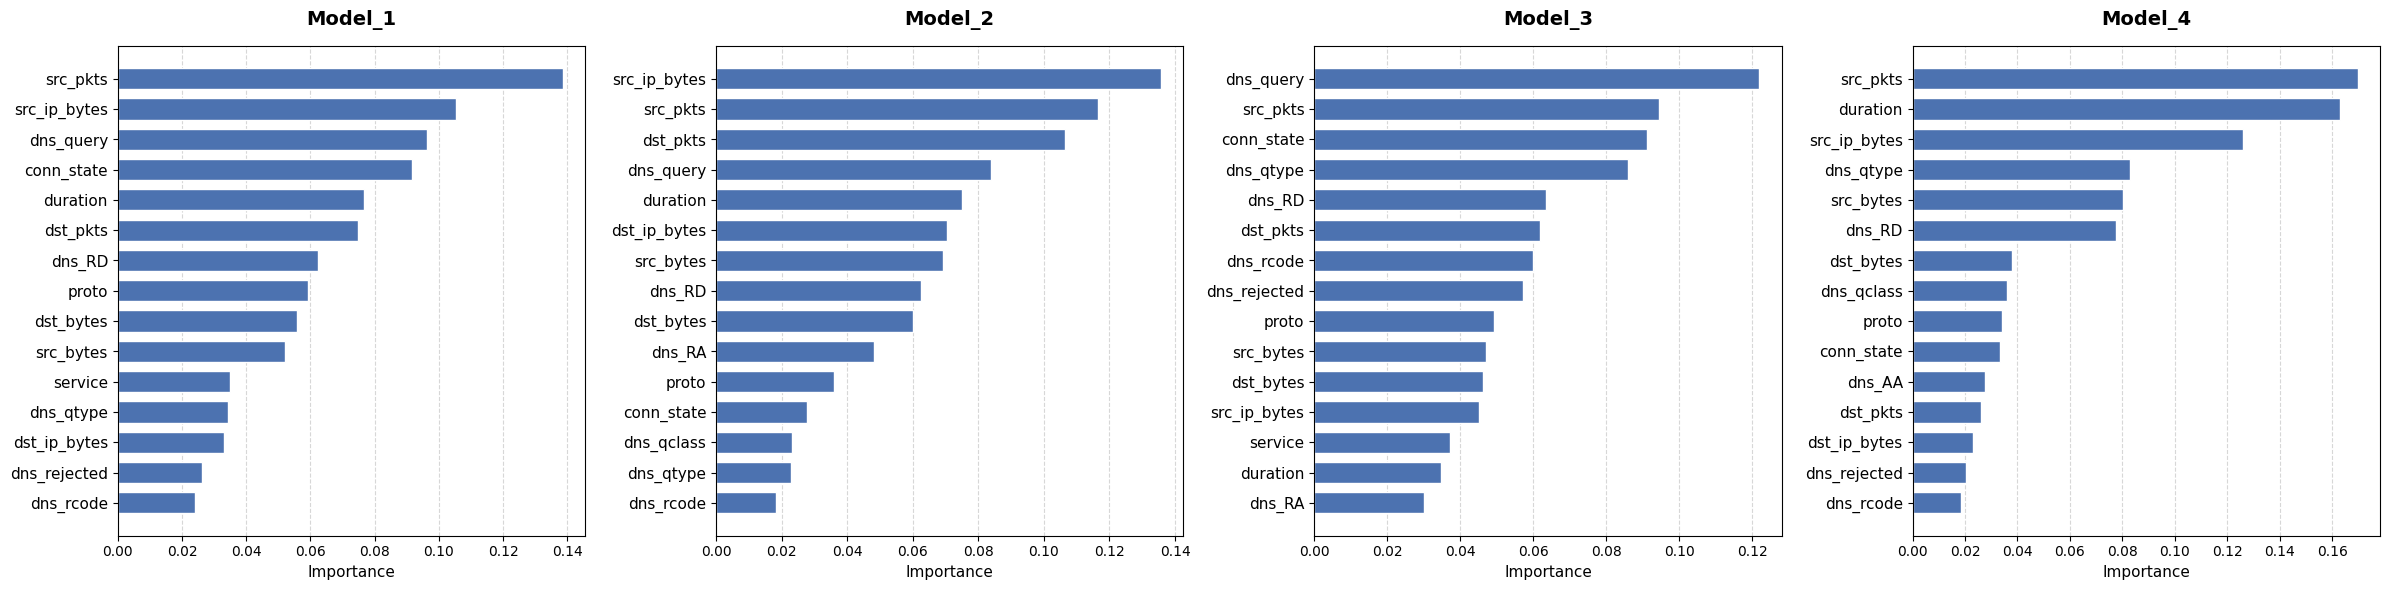

In [ ]:
from ton_iot_utils import plot_feature_importances

models = {
    'iforest': iforest,
    'eif': eif,
    'sciforest': sciforest,
    'fcf': fcf
}

importances = plot_feature_importances(models, X_val, y_val)

### save models to pickle files

In [67]:
import pickle
models = ["iforest", "eif", "sciforest", "fcf"]
for model_name in models:
    model = locals()[model_name]
    with open(f"{model_name}_model.pkl", "wb") as f:
        pickle.dump(model, f)
